# 02 - preprocesado

## Proyecto
**Clasificación de razas de perros y gatos con CNN y Transfer Learning**  
Dataset: **Oxford-IIIT Pet Dataset**

## Objetivo de este notebook
En este notebook se construye el pipeline de preprocesado que servirá como base para los modelos del proyecto.

### Lo que haremos
1. cargar el dataset con una partición de entrenamiento, validación y prueba,
2. redimensionar las imágenes a un tamaño fijo,
3. transformar cada ejemplo al formato `(imagen, etiqueta)`,
4. crear datasets listos para entrenamiento con `batch`, `shuffle`, `cache` y `prefetch`,
5. preparar una versión del pipeline para la **CNN base** y otra para **MobileNetV2**,
6. definir y visualizar una capa de **data augmentation**.

> Este notebook no entrena modelos. Su objetivo es dejar el preprocesado listo y documentado para los notebooks posteriores.

## 1. Importación de librerías

Usaremos:

- **tensorflow**: para manipular imágenes, construir pipelines con `tf.data` y definir capas de aumento de datos.
- **tensorflow_datasets**: para cargar el Oxford-IIIT Pet Dataset de manera reproducible.
- **matplotlib**: para visualizar imágenes procesadas y aumentadas.
- **numpy**: para operaciones auxiliares.

También fijamos una semilla para que el comportamiento del notebook sea más reproducible.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.20.0
TensorFlow Datasets version: 4.9.10


## 2. Carga del dataset con partición de validación

El dataset original viene con particiones de **train** y **test**.  
Para entrenar modelos de manera correcta, crearemos además una partición de **validación** a partir del conjunto de entrenamiento.

### Estrategia
Usaremos:
- `train[:80%]` para entrenamiento,
- `train[80%:]` para validación,
- `test` para prueba final.

### Por qué hacemos esto
- **train**: sirve para ajustar los pesos del modelo,
- **validation**: sirve para monitorear el desempeño durante entrenamiento y ajustar decisiones,
- **test**: se reserva para la evaluación final del modelo.

In [2]:
dataset_name = "oxford_iiit_pet"

(train_raw, val_raw, test_raw), info = tfds.load(
    dataset_name,
    split=["train[:80%]", "train[80%:]", "test"],
    with_info=True,
    as_supervised=False
)

class_names = info.features["label"].names
num_classes = info.features["label"].num_classes

print("Número de clases:", num_classes)
print("Tamaño train original:", info.splits["train"].num_examples)
print("Tamaño test original:", info.splits["test"].num_examples)
print("Cardinalidad train creada:", tf.data.experimental.cardinality(train_raw).numpy())
print("Cardinalidad val creada:", tf.data.experimental.cardinality(val_raw).numpy())
print("Cardinalidad test:", tf.data.experimental.cardinality(test_raw).numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Número de clases: 37
Tamaño train original: 3680
Tamaño test original: 3669
Cardinalidad train creada: 2944
Cardinalidad val creada: 736
Cardinalidad test: 3669


## 3. Definición de hiperparámetros del pipeline

Aquí definimos algunos valores globales del preprocesado.

### Variables
- **IMG_SIZE**: tamaño objetivo de las imágenes.
- **BATCH_SIZE**: número de imágenes por lote.
- **SHUFFLE_BUFFER**: tamaño del buffer de mezcla para el conjunto de entrenamiento.

### Decisiones
Se usará `224x224` porque:
- es un tamaño estándar en clasificación de imágenes,
- funciona bien con arquitecturas como MobileNetV2,
- reduce el costo computacional frente a tamaños mayores.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("SHUFFLE_BUFFER:", SHUFFLE_BUFFER)

IMG_SIZE: (224, 224)
BATCH_SIZE: 32
SHUFFLE_BUFFER: 1000


## 4. Inspección rápida del formato original

Antes de transformar los datos, verificamos cómo luce un ejemplo crudo del dataset.

In [4]:
example = next(iter(train_raw))
print("Claves:", example.keys())
print("Shape imagen original:", example["image"].shape)
print("Tipo imagen original:", example["image"].dtype)
print("Etiqueta:", int(example["label"].numpy()))
print("Clase:", class_names[int(example["label"].numpy())])

Claves: dict_keys(['file_name', 'head_bbox', 'image', 'label', 'segmentation_mask', 'species'])
Shape imagen original: (500, 500, 3)
Tipo imagen original: <dtype: 'uint8'>
Etiqueta: 33
Clase: Sphynx


## 5. Función básica de preprocesado

Esta función hace la transformación principal que necesitaremos en todos los modelos.

### Pasos
1. toma un ejemplo del dataset,
2. extrae la imagen y la etiqueta,
3. convierte la imagen a `float32`,
4. redimensiona la imagen a `224x224`,
5. aplica el tipo de normalización seleccionado,
6. devuelve una tupla `(image, label)`.

### Modos de normalización
- **"zero_one"**: escala los valores de píxel al rango `[0, 1]`.  
  Este modo es apropiado para la CNN base.
- **"mobilenet_v2"**: usa `tf.keras.applications.mobilenet_v2.preprocess_input`, que transforma la imagen al rango esperado por MobileNetV2.  
  Este modo será útil en el notebook de transfer learning.
- **None**: no aplica normalización adicional; solo hace cast y resize.

In [5]:
def preprocess_example(example, img_size=IMG_SIZE, normalize_mode="zero_one"):
    image = example["image"]
    label = example["label"]

    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, img_size)

    if normalize_mode == "zero_one":
        image = image / 255.0
    elif normalize_mode == "mobilenet_v2":
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    elif normalize_mode is None:
        pass
    else:
        raise ValueError("normalize_mode debe ser 'zero_one', 'mobilenet_v2' o None")

    return image, label

## 6. Función para construir datasets listos para entrenamiento

Esta función encapsula el pipeline completo con `tf.data`.

### Operaciones usadas
- **map**: aplica el preprocesado a cada ejemplo.
- **cache**: guarda en memoria los resultados del preprocesado para acelerar iteraciones posteriores.
- **shuffle**: mezcla los ejemplos del conjunto de entrenamiento.
- **batch**: agrupa ejemplos en lotes.
- **prefetch**: prepara lotes por adelantado para mejorar el rendimiento.

### Importante
Solo el conjunto de entrenamiento se mezcla (`shuffle=True`) porque en validación y prueba no es necesario alterar el orden.

In [6]:
def build_dataset(
    ds,
    training=False,
    normalize_mode="zero_one",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle_buffer=SHUFFLE_BUFFER
):
    ds = ds.map(
        lambda x: preprocess_example(x, img_size=img_size, normalize_mode=normalize_mode),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.cache()

    if training:
        ds = ds.shuffle(shuffle_buffer, seed=SEED)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

## 7. Construcción del pipeline para la CNN base

Primero creamos la versión del pipeline pensada para la línea base.  
En este caso, usaremos normalización **[0, 1]** porque es una opción simple y apropiada para una CNN construida desde cero.

In [7]:
train_ds_baseline = build_dataset(train_raw, training=True, normalize_mode="zero_one")
val_ds_baseline = build_dataset(val_raw, training=False, normalize_mode="zero_one")
test_ds_baseline = build_dataset(test_raw, training=False, normalize_mode="zero_one")

print("Datasets baseline creados correctamente.")

Datasets baseline creados correctamente.


## 8. Construcción del pipeline para MobileNetV2

Ahora creamos otra variante del pipeline, pensada específicamente para el notebook de transfer learning.

### Por qué otra versión
MobileNetV2 espera una transformación particular de entrada.  
Por eso, en lugar de una normalización genérica `[0, 1]`, aquí usamos la función oficial:

`tf.keras.applications.mobilenet_v2.preprocess_input`

Esta función adapta los valores al rango esperado por la arquitectura preentrenada.

In [8]:
train_ds_mobilenet = build_dataset(train_raw, training=True, normalize_mode="mobilenet_v2")
val_ds_mobilenet = build_dataset(val_raw, training=False, normalize_mode="mobilenet_v2")
test_ds_mobilenet = build_dataset(test_raw, training=False, normalize_mode="mobilenet_v2")

print("Datasets MobileNetV2 creados correctamente.")

Datasets MobileNetV2 creados correctamente.


## 9. Verificación del pipeline base

Vamos a inspeccionar un lote de entrenamiento de la versión baseline.

### Qué queremos verificar
- forma del tensor de imágenes,
- forma del tensor de etiquetas,
- tipo de dato,
- rango de valores después de normalizar.

In [9]:
images_batch, labels_batch = next(iter(train_ds_baseline))

print("Shape del lote de imágenes:", images_batch.shape)
print("Shape del lote de etiquetas:", labels_batch.shape)
print("Tipo de dato de imágenes:", images_batch.dtype)
print("Valor mínimo del lote:", tf.reduce_min(images_batch).numpy())
print("Valor máximo del lote:", tf.reduce_max(images_batch).numpy())

Shape del lote de imágenes: (32, 224, 224, 3)
Shape del lote de etiquetas: (32,)
Tipo de dato de imágenes: <dtype: 'float32'>
Valor mínimo del lote: 0.0
Valor máximo del lote: 1.0


## 10. Verificación del pipeline MobileNetV2

Aquí repetimos la inspección, pero para la versión compatible con MobileNetV2.

In [10]:
images_batch_m, labels_batch_m = next(iter(train_ds_mobilenet))

print("Shape del lote de imágenes:", images_batch_m.shape)
print("Shape del lote de etiquetas:", labels_batch_m.shape)
print("Tipo de dato de imágenes:", images_batch_m.dtype)
print("Valor mínimo del lote:", tf.reduce_min(images_batch_m).numpy())
print("Valor máximo del lote:", tf.reduce_max(images_batch_m).numpy())

Shape del lote de imágenes: (32, 224, 224, 3)
Shape del lote de etiquetas: (32,)
Tipo de dato de imágenes: <dtype: 'float32'>
Valor mínimo del lote: -1.0
Valor máximo del lote: 1.0


## 11. Visualización de imágenes preprocesadas (baseline)

Mostraremos algunas imágenes del pipeline baseline ya redimensionadas y normalizadas.

### Nota importante
Aunque internamente las imágenes están en `[0, 1]`, `matplotlib` puede visualizarlas correctamente.

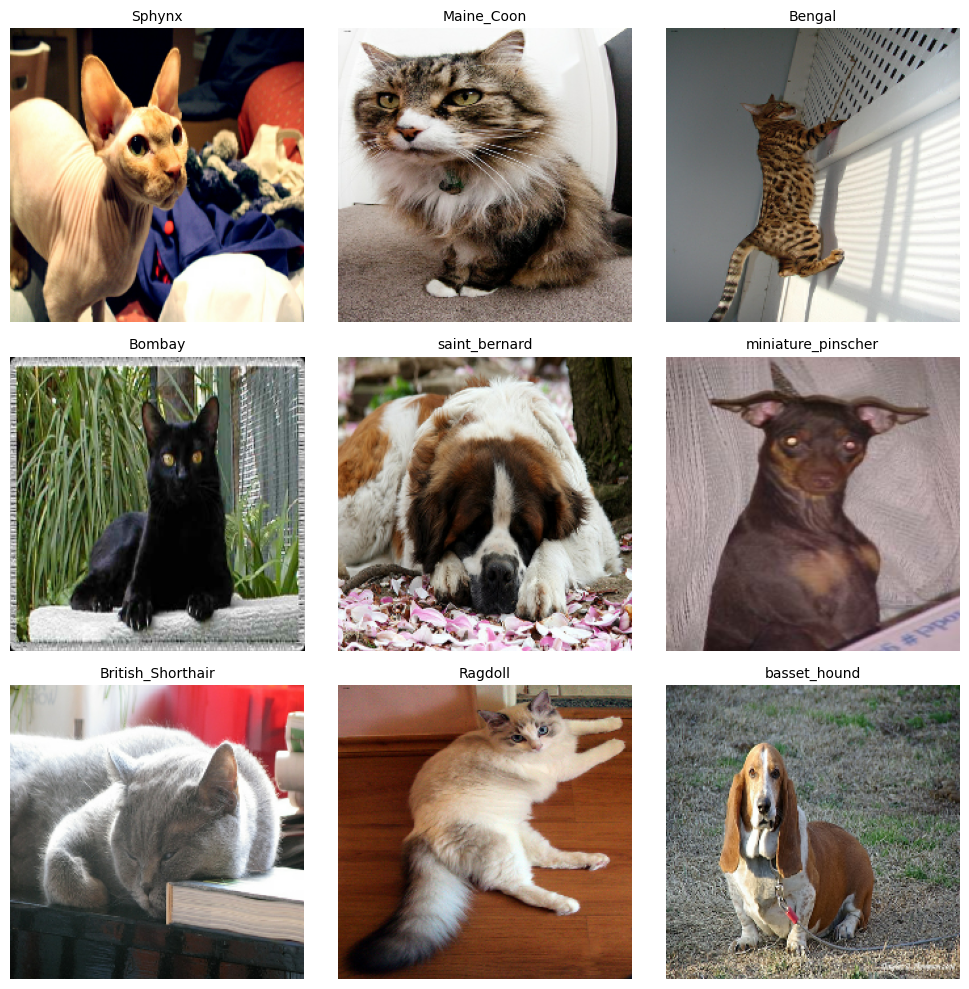

In [11]:
def show_batch(images, labels, class_names, n=9, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])], fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(images_batch.numpy(), labels_batch.numpy(), class_names, n=9)

## 12. Definición de data augmentation

El aumento de datos ayuda a mejorar la generalización del modelo generando variaciones razonables de las imágenes durante entrenamiento.

### Transformaciones seleccionadas
- **RandomFlip("horizontal")**: invierte horizontalmente algunas imágenes.
- **RandomRotation(0.1)**: rota levemente la imagen.
- **RandomZoom(0.1)**: aplica pequeños cambios de zoom.

### Por qué no exageramos las transformaciones
En clasificación de razas, cambios extremos podrían deformar demasiado la imagen y perjudicar el aprendizaje.  
Por eso usamos transformaciones suaves.

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

## 13. Visualización del efecto del data augmentation

Tomaremos una sola imagen ya preprocesada y aplicaremos varias transformaciones para ver el efecto visual del aumento de datos.

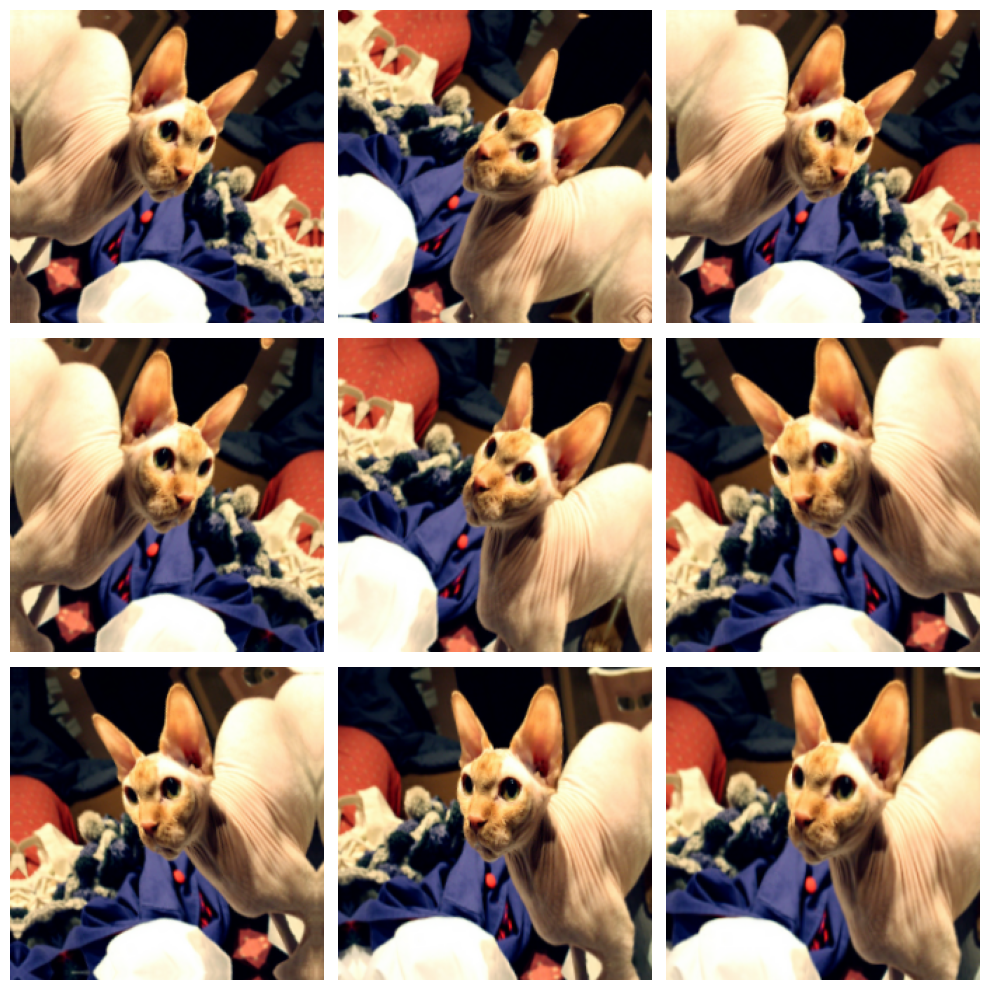

In [13]:
sample_image = images_batch[0]

plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_image = data_augmentation(tf.expand_dims(sample_image, axis=0), training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(tf.clip_by_value(augmented_image[0], 0.0, 1.0))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 14. Resumen del pipeline preparado

En este punto ya tenemos:

- `train_ds_baseline`, `val_ds_baseline`, `test_ds_baseline`
- `train_ds_mobilenet`, `val_ds_mobilenet`, `test_ds_mobilenet`
- `data_augmentation`

### Cómo se usarán después
- **Notebook 03**: usará la versión baseline (`zero_one`) para entrenar una CNN simple.
- **Notebook 04**: usará la versión MobileNetV2 para transfer learning.
- **Notebook 05**: reutilizará el pipeline MobileNetV2 para fine-tuning y evaluación final.

In [14]:
print("Resumen final:")
print("- Baseline train:", train_ds_baseline)
print("- Baseline val:", val_ds_baseline)
print("- Baseline test:", test_ds_baseline)
print("- MobileNet train:", train_ds_mobilenet)
print("- MobileNet val:", val_ds_mobilenet)
print("- MobileNet test:", test_ds_mobilenet)
print("- Data augmentation:", data_augmentation)

Resumen final:
- Baseline train: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
- Baseline val: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
- Baseline test: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
- MobileNet train: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
- MobileNet val: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
- MobileNet test: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), Tenso

## 15. Conclusiones del preprocesado

A partir de este notebook, el proyecto ya cuenta con una etapa de preprocesado reproducible y lista para ser usada por distintos modelos.

### Decisiones principales tomadas
1. Se creó una partición de validación a partir del conjunto de entrenamiento.
2. Se fijó un tamaño de entrada de **224x224** para todas las imágenes.
3. Se construyeron dos pipelines:
   - uno para la CNN base con normalización `[0, 1]`,
   - otro para MobileNetV2 con el preprocesamiento oficial de la arquitectura.
4. Se incorporaron optimizaciones del pipeline con `cache`, `shuffle`, `batch` y `prefetch`.
5. Se definió una etapa de **data augmentation** moderada para mejorar la generalización.

Este pipeline será la base para el entrenamiento y la comparación de modelos en los siguientes notebooks.